In [1]:
import os
import mujoco
import mujoco_viewer
import mujoco._render
import numpy as np
import qmt
import kinematics_and_jacobian.J_pos_ypr_fk_base_link_left_toe_motor_jax as Jacobian_left
import kinematics_and_jacobian.J_pos_ypr_fk_base_link_right_toe_motor_jax as Jacobian_right
import kinematics_and_jacobian.pos_quaternion_fk_base_link_left_toe_jax as forward_kinematic_left_body
import kinematics_and_jacobian.pos_quaternion_fk_base_link_right_toe_jax as forward_kinematic_right_body

import kinematics_and_jacobian.pos_quaternion_fk_origin_left_toe_jax as forward_kinematic_left
import kinematics_and_jacobian.pos_quaternion_fk_origin_right_toe_jax as forward_kinematic_right

import jax
from jax import jit
import jax.numpy as jnp
jax.config.update('jax_platform_name', 'cpu')

import matplotlib.pyplot as plt
import invers_kinematic_levenberg_marquardt as inverse_kinematic
from scipy.spatial.transform import Rotation as R

In [2]:
model = mujoco.MjModel.from_xml_path('/home/martin/Bachelorarbeit/DIGIT/digit-v3_stl/digit-v3.xml') # create the Model from Path
data = mujoco.MjData(model) # creates the data

In [3]:
''' Operator Input; Führungsgröße; Reference Input '''
q_hip_roll_vel_desired = 0
q_hip_yaw_vel_desired = 0
q_hip_pitch_vel_desired = 0
q_knee_vel_desired = 0
q_toe_pitch_vel_desired = 0

q_vels_desired = np.array([q_hip_roll_vel_desired, q_hip_yaw_vel_desired, q_hip_pitch_vel_desired, q_knee_vel_desired, q_toe_pitch_vel_desired])

In [4]:
actuator_names = [
    'left-hip-roll',
    'left-hip-yaw' ,
    'left-hip-pitch',
    'left-knee' ,
    'left-toe-A',
    'left-toe-B',
    'right-hip-roll' ,
    'right-hip-yaw' ,
    'right-hip-pitch' ,
    'right-knee' ,
    'right-toe-A' ,
    'right-toe-B' ,
    'left-shoulder-roll' ,
    'left-shoulder-pitch' ,
    'left-shoulder-yaw' ,
    'left-elbow' ,
    'right-shoulder-roll' ,
    'right-shoulder-pitch' ,
    'right-shoulder-yaw',
    'right-elbow' ,
]

In [5]:
# Damping per joint from hardware
damping_limit = np.array([66.849046,
                          26.112909,
                          38.05002,
                          38.05002,
                          28.553161,
                          28.553161,
                          66.849046,
                          26.112909,
                          38.05002,
                          38.05002,
                          28.553161,
                          28.553161,
                          66.849046,
                          66.849046,
                          26.112909,
                          66.849046,
                          66.849046,
                          66.849046,
                          26.112909,
                          66.849046,
                          ])

In [6]:
kd = 1 # 0.9 #0.6

In [7]:
jnt_dofadr= [model.jnt_dofadr[mujoco.mj_name2id(model,3, name)]for name in actuator_names]

In [8]:
def set_start_position():
    ''' Sets the angle of the joints --> results in a Start Position '''
    only_z = False

    if only_z == False:

        data.qpos[2] = 0.91 # z-position
        data.qpos[7] = np.deg2rad(18)  # left-hip-roll  
        data.qpos[8] = 0.0  # left-hip-yaw
        data.qpos[9] = 0.17 # left-hip-pitch
        data.qpos[10] = 0.04 # left-achillies-rod
        data.qpos[11] = 0.01 # ich glaube 11 existiert nicht
        data.qpos[31] = np.deg2rad(50) # left-shoulder-pitch # Arme hängen lassen
        data.qpos[33] = np.deg2rad(60)# left-elbow 
        data.qpos[34] = -np.deg2rad(18) # right-hip-roll
        data.qpos[35] = 0.0 # right-hip-yaw
        data.qpos[36] = -0.17 # right-hip-pitch
        data.qpos[37] = -0.04 # right-achillies-rod
        data.qpos[38] = 0.01 # exisitiert wahrscheinlich nicht
        data.qpos[58] = -np.deg2rad(50) # left-shoulder-pitch
        data.qpos[60] = -np.deg2rad(60) # right-elbow

    else:
        ''' Only Z-Axis '''    
        data.qpos[1] = np.deg2rad(18)  # left-hip-roll
        data.qpos[2] = 0.0  # left-hip-yaw
        data.qpos[3] = 0.17 # left-hip-pitch
        data.qpos[4] = 0.04 
        data.qpos[5] = 0.01
        # data.qpos[31] = np.deg2rad(50)# Test by Martin # Arme hängen lassen
        # data.qpos[33] = np.deg2rad(60)# Test by Martin
        data.qpos[28] = -np.deg2rad(18) # right-hip-roll
        data.qpos[29] = 0.0 # right-hip-yaw
        data.qpos[30] = -0.17 # right-hip-pitch
        data.qpos[31] = -0.04
        data.qpos[32] = 0.01
        # data.qpos[52] = -np.deg2rad(50) # Test by Martin
        # data.qpos[54] = -np.deg2rad(60) # Test by Martin



    # Wenn ich nur in Z bin muss ich 6 abziehen weil die freiheitsgrade weg gehen

''' The Jacobian gets 34 items as input '''
['base_x', 'base_y', 'base_z', 'base_yaw', 'base_pitch', 'base_roll', 
 'hip_abduction_left', 'hip_rotation_left', 'hip_flexion_left', 'knee_joint_left', 'knee_to_shin_left', 'shin_to_tarsus_left', 'toe_A_rod_joint_left', 'toe_B_rod_joint_left', 'toe_pitch_joint_left', 'toe_roll_joint_left', 
 'hip_abduction_right', 'hip_rotation_right', 'hip_flexion_right', 'knee_joint_right', 'knee_to_shin_right', 'shin_to_tarsus_right', 'toe_A_rod_joint_right', 'toe_B_rod_joint_right', 'toe_pitch_joint_right', 'toe_roll_joint_right', 
 'shoulder_roll_joint_left', 'shoulder_pitch_joint_left', 'shoulder_yaw_joint_left', 'elbow_joint_left', 'shoulder_roll_joint_right', 'shoulder_pitch_joint_right', 'shoulder_yaw_joint_right', 'elbow_joint_right']

In [9]:
def configuration_space_function(sensordata):
    ''' Gelenkwinkel '''    
    base_pos = sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "base-pos")]:3] # Sensor_adress 1st to 3rd

    base_quat = sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "base-quat")]:model.sensor_adr[mujoco.mj_name2id(model, 19, "base-quat")] + 4] # +4 bcs the quaternion has 4 items
    pelvis_orientation = qmt.eulerAngles(base_quat) # transform the quaternion to euler angles z y x 

    joint_poses = sensordata[7:35]
    
    configuration_space_vector = np.concatenate((base_pos, pelvis_orientation, joint_poses), axis=0)

    return configuration_space_vector  

In [10]:
''' Gains '''
Kp_hip_roll = 600
Kp_hip_yaw = 600
Kp_hip_pitch = 600
Kp_knee = 600
Kp_toe_pitch = 400

Kd_hip_roll = 60
Kd_hip_yaw = 60
Kd_hip_pitch = 60
Kd_knee = 60
Kd_toe_pitch = Kp_toe_pitch / 10

gains = np.array([Kp_hip_roll, Kp_hip_yaw, Kp_hip_pitch, Kp_knee, Kp_toe_pitch, Kd_hip_roll, Kd_hip_yaw, Kd_hip_pitch, Kd_knee, Kd_toe_pitch])

In [11]:
def configuration_space_error_function(configuration_space_vector_desired, configuration_space_vector, pelvis_pitch_theta):

    ''' q-errors , configuration space errors'''
    q_left_hip_roll_error  = configuration_space_vector_desired[6]  - configuration_space_vector[6]
    q_left_hip_yaw_error   = configuration_space_vector_desired[7]  - configuration_space_vector[7]
    q_left_hip_pitch_error = configuration_space_vector_desired[8]  - configuration_space_vector[8] + pelvis_pitch_theta-np.deg2rad(0)
    q_left_knee_error      = configuration_space_vector_desired[9]  - configuration_space_vector[9]
    q_left_toe_pitch_error = configuration_space_vector_desired[14] - configuration_space_vector[14] + pelvis_pitch_theta

    q_right_hip_roll_error  = configuration_space_vector_desired[16] - configuration_space_vector[16]
    q_right_hip_yaw_error   = configuration_space_vector_desired[17] - configuration_space_vector[17]
    q_right_hip_pitch_error = configuration_space_vector_desired[18] - configuration_space_vector[18] - pelvis_pitch_theta + np.deg2rad(0)
    q_right_knee_error      = configuration_space_vector_desired[19] - configuration_space_vector[19]
    q_right_toe_pitch_error = configuration_space_vector_desired[24] - configuration_space_vector[24] - pelvis_pitch_theta


    return np.array([
        q_left_hip_roll_error, 
        q_left_hip_yaw_error, 
        q_left_hip_pitch_error, 
        q_left_knee_error, 
        q_left_toe_pitch_error, 
        q_right_hip_roll_error, 
        q_right_hip_yaw_error, 
        q_right_hip_pitch_error, 
        q_right_knee_error, 
        q_right_toe_pitch_error
    ])

In [12]:
def velocity_error_function(q_vels_desired, sensordata):
    ''' q-vel-errors '''    
    q_left_hip_roll_vel_error  = q_vels_desired[0]  - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "left-hip-roll-vel")]]
    q_left_hip_yaw_vel_error   = q_vels_desired[1]  - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "left-hip-yaw-vel")]]
    q_left_hip_pitch_vel_error = q_vels_desired[2]  - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "left-hip-pitch-vel")]]
    q_left_knee_vel_error      = q_vels_desired[3]  - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "left-knee-vel")]]
    q_left_toe_pitch_vel_error = q_vels_desired[4]  - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "left-toe-pitch-vel")]]

    q_right_hip_roll_vel_error  = q_vels_desired[0] - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "right-hip-roll-vel")]]
    q_right_hip_yaw_vel_error   = q_vels_desired[1] - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "ght-hip-yaw-vel")]]
    q_right_hip_pitch_vel_error = q_vels_desired[2] - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "right-hip-pitch-vel")]]
    q_right_knee_vel_error      = q_vels_desired[3] - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "right-knee-vel")]]
    q_right_toe_pitch_vel_error = q_vels_desired[4] - sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "right-toe-pitch-vel")]]

    return np.array([
        q_left_hip_roll_vel_error, 
        q_left_hip_yaw_vel_error, 
        q_left_hip_pitch_vel_error, 
        q_left_knee_vel_error, 
        q_left_toe_pitch_vel_error, 
        q_right_hip_roll_vel_error, 
        q_right_hip_yaw_vel_error, 
        q_right_hip_pitch_vel_error,
        q_right_knee_vel_error,
        q_right_toe_pitch_vel_error
    ])

In [13]:
def PD_Controller(gains, configuration_space_error_vector, velocity_errors_vector, torques_left, torques_right):
    ''' Calculates torques for left and right leg ''' 
    #torques_left = np.zeros(5)
    #torques_right = np.zeros(5)
    torques_left[0]  = gains[0] * configuration_space_error_vector[0] + gains[5] * velocity_errors_vector[0]
    torques_left[1]  = gains[1] * configuration_space_error_vector[1] + gains[6] * velocity_errors_vector[1]
    torques_left[2]  = gains[2] * configuration_space_error_vector[2] + gains[7] * velocity_errors_vector[2]
    torques_left[3]  = gains[3] * configuration_space_error_vector[3] + gains[8] * velocity_errors_vector[3]
    torques_left[4]  = gains[4] * configuration_space_error_vector[4] + gains[9] * velocity_errors_vector[4]

    torques_right[0] = gains[0] * configuration_space_error_vector[5] + gains[5] * velocity_errors_vector[5]
    torques_right[1] = gains[1] * configuration_space_error_vector[6] + gains[6] * velocity_errors_vector[6]
    torques_right[2] = gains[2] * configuration_space_error_vector[7] + gains[7] * velocity_errors_vector[7]
    torques_right[3] = gains[3] * configuration_space_error_vector[8] + gains[8] * velocity_errors_vector[8]
    torques_right[4] = gains[4] * configuration_space_error_vector[9] + gains[9] * velocity_errors_vector[9]

    return torques_left, torques_right

In [14]:
def gravity_compensation(pelvis_y_world, pose_left_leg_body, pose_right_leg_body, configuration_space_vector, previous_value):
    ''' Gravity Compensation and Center of pressure '''
    change = previous_value - pelvis_y_world
    #center_of_pressure_desired = pelvis_y_world - 1.2 * (0 - pelvis_y_world)# ohne dämpfung
    center_of_pressure_desired = pelvis_y_world - 1.2 * (0 - pelvis_y_world) + 1.2 * change # mit dämpfung
    weight_robot = 48 * (-9.81)      
    Cr = (center_of_pressure_desired - pose_right_leg_body[1]) / (np.absolute(pose_left_leg_body[1]) + np.absolute(pose_right_leg_body[1]))
    Cr = np.clip(Cr, 0, 1)
    force_left = weight_robot * Cr 
    force_right = weight_robot - force_left
    force_right_vector = np.array([0, 0, force_right ,0 ,0 ,0])
    force_left_vector = np.array([0, 0, force_left ,0 ,0 ,0])
    Jacobian_matrix_left = Jacobian_left.J_pos_ypr_fk_base_link_left_toe_motor(configuration_space_vector)
    Jacobian_matrix_right = Jacobian_right.J_pos_ypr_fk_base_link_right_toe_motor(configuration_space_vector)
    Jacobian_matrix_left_transpose = np.transpose(Jacobian_matrix_left)
    Jacobian_matrix_right_transpose = np.transpose(Jacobian_matrix_right)
    torques_gravity_left = Jacobian_matrix_left_transpose @ force_left_vector
    torques_gravity_right = Jacobian_matrix_right_transpose @ force_right_vector
    torques_gravity_left = torques_gravity_left[:-1] # remove last element ( toe roll)
    torques_gravity_right = torques_gravity_right[:-1]

    previous_value = pelvis_y_world

    return torques_gravity_left, torques_gravity_right

In [15]:
def first_order_filter(tau, tau_old, alpha):
    return tau * alpha + tau_old * (1- alpha)

In [16]:
def actuate_motor(torques_left, torques_right):
    ''' Actuate Motors '''
    data.ctrl[0] =  torques_left[0] / 80 # left-hip-roll
    data.ctrl[1] =  torques_left[1] / 50 # left-hip-yaw
    data.ctrl[2] =  torques_left[2] / 16 # left-hip-pitch 
    data.ctrl[3] =  torques_left[3] / 16 # left-knee
    data.ctrl[4] =  -torques_left[4] / 50  / 2 # left-toe-A
    data.ctrl[5] = torques_left[4] / 50 / 2  # left-toe-B 


    data.ctrl[6]  = torques_right[0] / 80 # right-hip-roll 
    data.ctrl[7]  = torques_right[1] / 50 # right-hip-yaw 
    data.ctrl[8]  = torques_right[2] / 16 # right-hip-pitch
    data.ctrl[9]  = torques_right[3] / 16 # right-knee
    data.ctrl[10] = -torques_right[4] / 50  / 2 # right-toe-A
    data.ctrl[11] = torques_right[4] / 50 / 2  # right-toe-B

In [17]:
data = mujoco.MjData(model) # creates the data
''' Start Position '''
set_start_position()
render_mujoco = True
if render_mujoco == True:
    viewer = mujoco_viewer.MujocoViewer(model, data)

# Perform an initial simulation step to update sensor data
mujoco.mj_forward(model, data) # ich brauche das weil damit die Sensordata vor dem ersten Loop geupdatet ist

max_torques = np.array([
    1.4 * 80, 
    1.4 * 50,
    12.5* 16,
    12.5* 16,
    0.9 * 50,
    #0.9 * 50,
]) 
sensordata = data.sensordata.copy()

torques_left = np.zeros(5)
torques_right = np.zeros(5)
last_tau_left = np.zeros_like(torques_left)
last_tau_right = np.zeros_like(torques_right)
errors_left = np.empty((10_000, 5))
errors_right = np.empty((10_000, 5))
pelvis_pos_plot = np.empty((10_000, 3))
pelvis_orientations = np.empty((10_000, 3))
pelvis_error_plot = np.empty((10_000, 3))
pelvis_pos_plot_damping = np.empty((10_000, 3))
tau_left_damp = np.empty((10_000, 5))
tau_right_damp = np.empty((10_000,5))

tau_left = np.empty((10_000, 5))
tau_right = np.empty((10_000,5))
left_world = np.empty((10_000, 6))
right_world = np.empty((10_000, 6))

previous_value = 0

# Kraftparameter 
force = np.array([0, 0, -500])  # Beispielkraft in die z-Richtung in Newton z = -500;   y = 90N
force_duration = 0.1  # Dauer der Kraftanwendung in Sekunden
force_start_time = 1  # Zeitpunkt der Kraftanwendung in Sekunden

# Beispielmoment in Newton-Metern (N·m)
moment = np.array([0, 0, 0])  # Moment in der z-Richtung 90Nm
# Dauer der Momentenanwendung in Sekunden
moment_duration = 0.1
# Zeitpunkt der Momentenanwendung in Sekunden
moment_start_time = 1

# simulate and render
for i in range(40_000):
    
        ''' Get Configuration Space; Joint Space; Gelenkwinkel; all q '''
        configuration_space_vector = configuration_space_function(sensordata) 

        ''' Get Pelvis Orientation in World Frame '''        
        base_quat = sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "base-quat")]:model.sensor_adr[mujoco.mj_name2id(model, 19, "base-quat")] + 4] # w x y z
        pelvis_orientation = qmt.eulerAngles(base_quat) # transform the quaternion to euler angles zyx
        pelvis_yaw_psi = pelvis_orientation[0]   
        pelvis_pitch_theta = pelvis_orientation[1]       
        pelvis_roll_phi = pelvis_orientation[2]
        pelvis_orientations[i] = np.array([pelvis_yaw_psi, pelvis_pitch_theta, pelvis_roll_phi])

        ''' Get Pelvis Position '''
        pelvis_pos_world = sensordata[model.sensor_adr[mujoco.mj_name2id(model, 19, "base-pos")]:3] # Pelvis Position in World Frame        
        pelvis_pos_plot[i] = pelvis_pos_world
        #pelvis_pos_plot_damping[i] = pelvis_pos_world
        ''' Get Leg Pose in World and Body '''
        pose_left_leg_body  = forward_kinematic_left_body.pos_quaternion_fk_base_link_left_toe(configuration_space_vector) # get Pose of left leg, xyzwrpy FK takes configuration space as input
        pose_right_leg_body = forward_kinematic_right_body.pos_quaternion_fk_base_link_right_toe(configuration_space_vector) # get Pose of right leg, FK takes configuration space as input

        pose_left_leg_world  = forward_kinematic_left.pos_quaternion_fk_origin_left_toe(configuration_space_vector) # get Pose of left leg in World Frame
        pose_right_leg_world = forward_kinematic_right.pos_quaternion_fk_origin_right_toe(configuration_space_vector) # get Pose of right leg in World Frame
        

        ''' Rotate Pelvis Position around Z '''
        rot_z = np.array([[np.cos(pelvis_yaw_psi), -np.sin(pelvis_yaw_psi), 0],
                          [np.sin(pelvis_yaw_psi), np.cos(pelvis_yaw_psi), 0],
                          [0,0,1]]) 
        pelvis_pos_world = rot_z.T @ pelvis_pos_world               
        

        ''' Rotate Legs Position around Z '''
        pose_left_leg_world = pose_left_leg_world.at[:3].set((rot_z.T @ np.array(pose_left_leg_world[:3])))      
        pose_right_leg_world = pose_right_leg_world.at[:3].set((rot_z.T @ np.array(pose_right_leg_world[:3])))


        ''' Error Handling '''
        left_z_relative_desired = -0.95 # Left foot z world relative tor pelvis desired  # weiß nicht
        right_z_relative_desired = -0.95 # right foot z world relative tor pelvis desired

        left_x_world_desired =  -0.025 # - pelvis_pos_world[0]  
        right_x_world_desired = -0.025 # -  pelvis_pos_world[0] 
        left_y_world_desired =  0.15  # - pelvis_pos_world[1]
        right_y_world_desired = -0.15 # - pelvis_pos_world[1] 
        left_z_world_desired = (left_z_relative_desired)  + (+ np.arcsin(pelvis_roll_phi) * 0.135)   
        right_z_world_desired = (right_z_relative_desired) + (- np.arcsin(pelvis_roll_phi) * 0.135)
          

                 
        left_world_desired_pos = np.array([left_x_world_desired, left_y_world_desired, left_z_world_desired]) #z = -0.95
        right_world_desired_pos = np.array([right_x_world_desired, right_y_world_desired, right_z_world_desired])

        # Umwandlung der Euler-Winkel der Pelvis Orientierung in Rotationsmatrix
        r_world_to_body = R.from_euler('zyx', pelvis_orientation).as_matrix()       
  
        pelvis_des = np.array([(pose_left_leg_world[0] + pose_right_leg_world[0]) / 2, (pose_left_leg_world[1] + pose_right_leg_world[1]) / 2, 0.95])

        pelvis_pos_world[2] = (pelvis_pos_world[2] - (pose_left_leg_world[2] + pose_right_leg_world[2]) / 2) # * 0.5 anstatt / 2 ## = ~0.95

        pelvis_error = pelvis_pos_world - pelvis_des
        pelvis_error_plot[i] = pelvis_error

        left_body_pos = np.dot(r_world_to_body, (left_world_desired_pos + pelvis_error))
        right_body_pos = np.dot(r_world_to_body, (right_world_desired_pos + pelvis_error))
        left_world[i,:3] = (left_world_desired_pos + pelvis_pos_world - pelvis_des )
        right_world[i,:3] = (right_world_desired_pos + pelvis_pos_world  - pelvis_des)
       

        if np.isnan(left_body_pos).any():
            print(left_body_pos)
            break


        pose_left_leg_body_desired = np.zeros(6)        
        pose_left_leg_body_desired[:3] = left_body_pos
        
        pose_right_leg_body_desired = np.zeros(6)
        pose_right_leg_body_desired[:3] = right_body_pos


        ''' Inverse Kinematic '''
        configuration_space_vector_desired = inverse_kinematic.legs_levenberg_marquardt(configuration_space_vector.copy(), pose_left_leg_body_desired, pose_right_leg_body_desired)

        configuration_space_error_vector = configuration_space_error_function(configuration_space_vector_desired, configuration_space_vector, pelvis_pitch_theta) # new
        velocity_errors_vector = velocity_error_function(q_vels_desired, sensordata) # new     

        errors_left[i] = configuration_space_error_vector[:5] # fill array for plot#
        errors_right[i] = configuration_space_error_vector[5:] # fill array for plot

        ''' PD-Controller ''' 
        torques_left, torques_right = PD_Controller(gains, configuration_space_error_vector, velocity_errors_vector, torques_left, torques_right) # new
        
        ''' Gravity Compensation ''' 
        torques_gravity_left, torques_gravity_right = gravity_compensation(pelvis_pos_world[1] ,pose_left_leg_world, pose_right_leg_world, configuration_space_vector, previous_value)

        ''' Combine torques '''
        torques_left += torques_gravity_left
        torques_right += torques_gravity_right

        ''' Clip Torques to real limits '''
        torques_left = np.clip(torques_left, -max_torques, max_torques)
        torques_right = np.clip(torques_right, -max_torques, max_torques)

        ''' Filter torques '''
        torques_left = first_order_filter(torques_left, last_tau_left, 0.5)
        torques_right = first_order_filter(torques_right, last_tau_right, 0.5)

        last_tau_left = torques_left
        last_tau_right = torques_right

        tau_left[i] = torques_left.squeeze()
        tau_right[i] = torques_right.squeeze()

        #tau_left_damp[i] = torques_left.squeeze()
        #tau_right_damp[i] = torques_right.squeeze()

        ''' Actuate motors '''
        actuate_motor(torques_left, torques_right)


        ''' Apply force at the specified time '''
        if force_start_time <= data.time < force_start_time + force_duration:
            # Apply force in the z-direction to the pelvis
            data.xfrc_applied[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "base"), :3] = force

        # Reset the force after the duration
        if data.time >= force_start_time + force_duration:
            data.xfrc_applied[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "base"), :3] = 0

        # Wende das Moment zum angegebenen Zeitpunkt an
        if moment_start_time <= data.time < moment_start_time + moment_duration:
            # Wende das Moment auf den Körper an
            body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "base")
            data.xfrc_applied[body_id, 3:] = moment  # Momentenanteil des xfrc_applied Arrays

        # Setze das Moment nach der Dauer zurück
        if data.time >= moment_start_time + moment_duration:
            data.xfrc_applied[body_id, 3:] = 0  # Moment zurücksetzen


        
        model.dof_damping[jnt_dofadr] = damping_limit * kd
        sensordata = data.sensordata.copy() # das braucht man anscheinend damit die Werte aktualisiert werden

        for _ in range(5):
            mujoco.mj_step(model, data)
        if render_mujoco:
            if viewer.is_alive:
                viewer.render()
            else:
                break
        if data.time > 100 or i > 40_000:
            break       


# close
if render_mujoco:
    viewer.close()

Pressed ESC
Quitting.


In [48]:
time2 = np.linspace(0, data.time, i)
pelvis_pos_plot_damping = pelvis_pos_plot_damping
time_cut2 = time2[time2 <= 12]

In [49]:
1/(0.000500*10)

time = np.linspace(0, data.time, i)
time_cut = time[time <= 12]

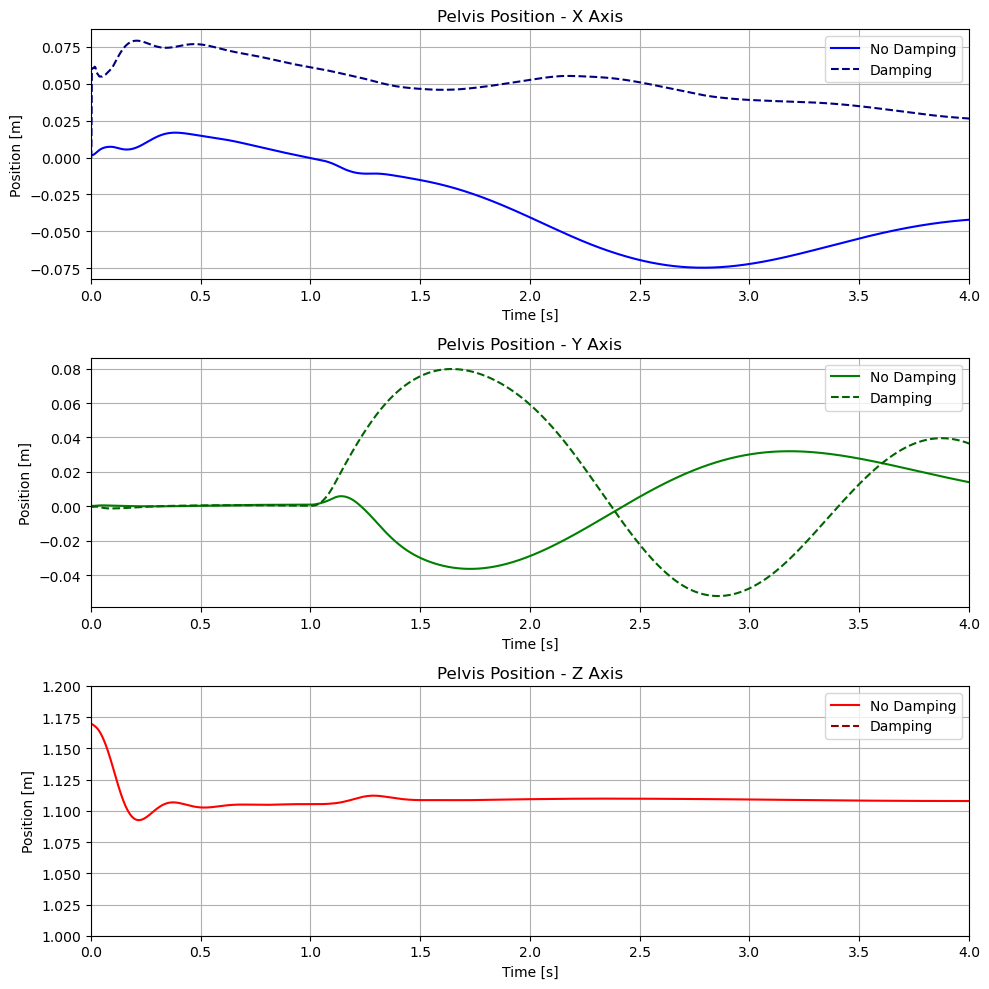

In [51]:
from matplotlib.colors import to_rgba
''' Pelvis Positon '''
# Erstelle die Unterplots
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

# Plot für die x-Komponente der Beckenposition
ax[0].plot(time, pelvis_pos_plot[:i, 0], color='blue', label='No Damping')
ax[0].plot(time2, pelvis_pos_plot_damping[:i, 0], color='navy', linestyle='--', label='Damping')
ax[0].grid(True)  # Gitternetzlinien hinzufügen
ax[0].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[0].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[0].set_title('Pelvis Position - X Axis')  # Titel hinzufügen
ax[0].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[0].set_ylabel('Position [m]')  # y-Achsenbeschriftung
ax[0].legend()

# Plot für die y-Komponente der Beckenposition
ax[1].plot(time, pelvis_pos_plot[:i, 1], color='green', label='No Damping')
ax[1].plot(time2, pelvis_pos_plot_damping[:i, 1], color='darkgreen', linestyle='--', label='Damping')
ax[1].grid(True)  # Gitternetzlinien hinzufügen
ax[1].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[1].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[1].set_title('Pelvis Position - Y Axis')  # Titel hinzufügen
ax[1].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[1].set_ylabel('Position [m]')  # y-Achsenbeschriftung
ax[1].legend()

# Plot für die z-Komponente der Beckenposition
ax[2].plot(time, pelvis_pos_plot[:i, 2], color='red', label='No Damping')
ax[2].plot(time2, pelvis_pos_plot_damping[:i, 2], color='darkred', linestyle='--', label='Damping')
ax[2].grid(True)  # Gitternetzlinien hinzufügen
ax[2].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[2].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[2].set_ylim(1, 1.2)
ax[2].set_title('Pelvis Position - Z Axis')  # Titel hinzufügen
ax[2].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[2].set_ylabel('Position [m]')  # y-Achsenbeschriftung
ax[2].legend()

# Layout-Anpassung für eine bessere Darstellung
plt.tight_layout()
#plt.savefig('Pelvis Position z-disturbance -500N.pdf')
#plt.savefig('Pelvis Position y-disturbance with and without damping 90N.pdf')

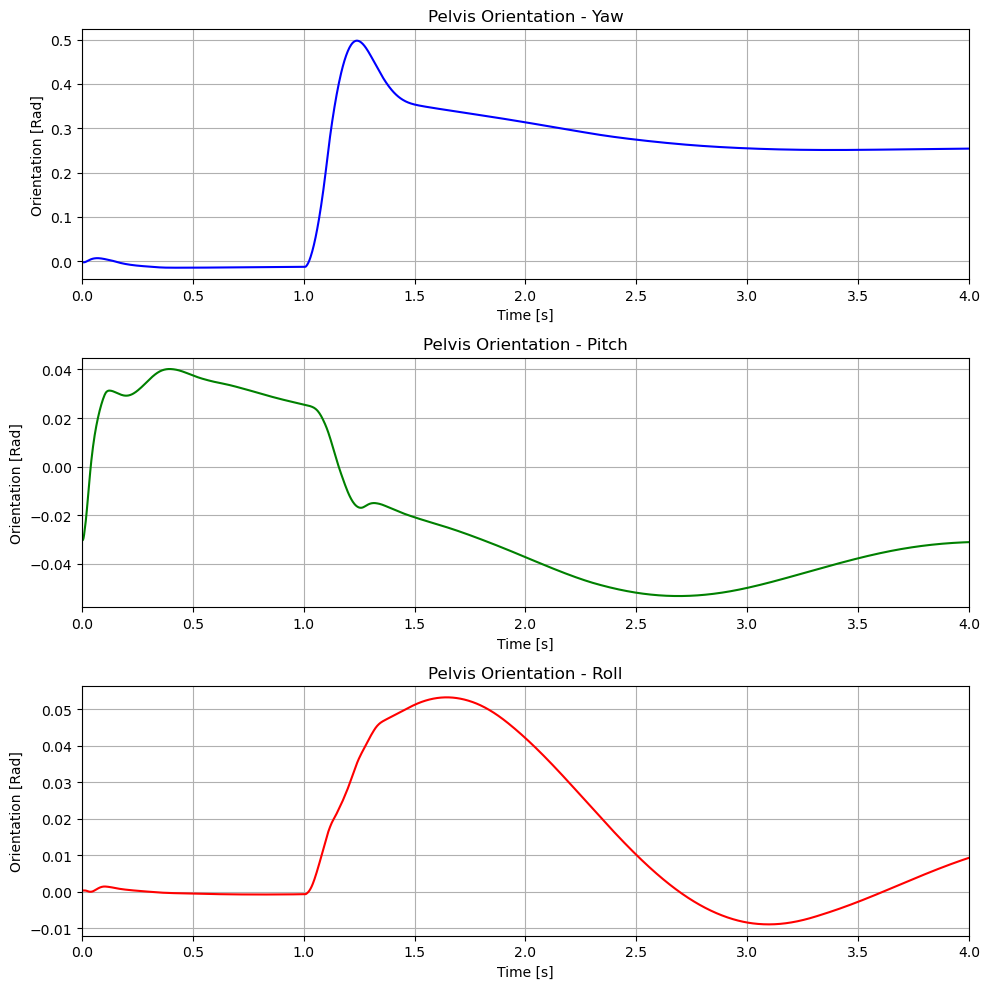

In [52]:
''' Pelvis Orientation '''
# Erstelle die Unterplots
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

# Plot für die x-Komponente der Beckenposition
ax[0].plot(time, pelvis_orientations[:i, 0], color='blue')
ax[0].grid(True)  # Gitternetzlinien hinzufügen
ax[0].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[0].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[0].set_title('Pelvis Orientation - Yaw')  # Titel hinzufügen
ax[0].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[0].set_ylabel('Orientation [Rad]')  # y-Achsenbeschriftung

# Plot für die y-Komponente der Beckenposition
ax[1].plot(time, pelvis_orientations[:i, 1], color='green')
ax[1].grid(True)  # Gitternetzlinien hinzufügen
ax[1].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[1].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[1].set_title('Pelvis Orientation - Pitch')  # Titel hinzufügen
ax[1].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[1].set_ylabel('Orientation [Rad]')  # y-Achsenbeschriftung

# Plot für die z-Komponente der Beckenposition
ax[2].plot(time, pelvis_orientations[:i, 2], color='red')
ax[2].grid(True)  # Gitternetzlinien hinzufügen
ax[2].set_xlim(left=0)  # Startet den Plot am linken Rand
ax[2].set_xlim(right=4)  # Startet den Plot am linken Rand
ax[2].set_title('Pelvis Orientation - Roll')  # Titel hinzufügen
ax[2].set_xlabel('Time [s]')  # x-Achsenbeschriftung
ax[2].set_ylabel('Orientation [Rad]')  # y-Achsenbeschriftung

# Layout-Anpassung für eine bessere Darstellung
plt.tight_layout()
plt.savefig('Pelvis Orientation yaw-disturbance 90Nm.pdf')

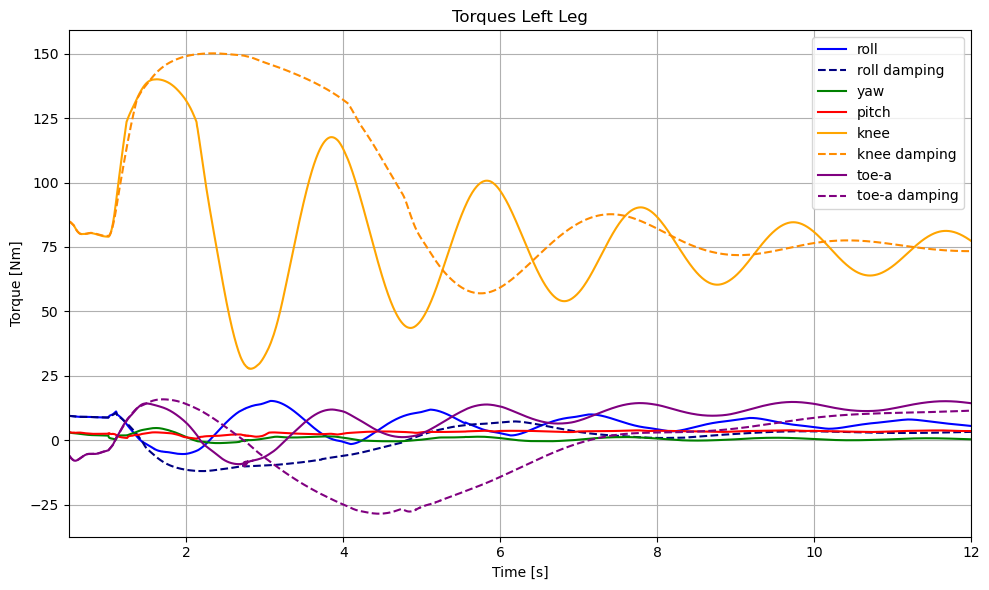

In [45]:
# Annahme: start_time ist der Zeitpunkt, ab dem geplottet werden soll
start_time = 0.5  # Beispielzeitpunkt in Sekunden
# Finde den Index, der am nächsten zu start_time liegt
start_index = np.where(time >= start_time)[0][0]
# Erstelle den Plot
fig, ax = plt.subplots(figsize=(10, 6))
# Plot für die roll-Komponente
ax.plot(time[start_index:], tau_left[start_index:i, 0], color='blue', label='roll')
ax.plot(time2[start_index:], tau_left_damp[start_index:i, 0], color='navy', label='roll damping', linestyle='--')
# Plot für die yaw-Komponente
ax.plot(time[start_index:], tau_left[start_index:i, 1], color='green', label='yaw')
#ax.plot(time2[start_index:], tau_left_damp[start_index:i, 1], color='darkgreen', label='yaw damping', linestyle='--')
# Plot für die pitch-Komponente
ax.plot(time[start_index:], tau_left[start_index:i, 2], color='red', label='pitch')
#ax.plot(time2[start_index:], tau_left_damp[start_index:i, 2], color='darkred', label='pitch damping', linestyle='--')
# Plot für die toe-a-Komponente
ax.plot(time[start_index:], tau_left[start_index:i, 3], color='orange', label='knee')
ax.plot(time2[start_index:], tau_left_damp[start_index:i, 3], color='darkorange', label='knee damping', linestyle='--')
# Plot für die toe-a-Komponente
ax.plot(time[start_index:], tau_left[start_index:i, 4], color='purple', label='toe-a')
ax.plot(time2[start_index:], tau_left_damp[start_index:i, 4], color='purple', label='toe-a damping', linestyle='--')
# Gitternetzlinien hinzufügen
ax.grid(True)
# Startet den Plot am linken Rand bei start_time
ax.set_xlim(left=start_time)
ax.set_xlim(right=12)
# Titel und Achsenbeschriftungen
ax.set_title('Torques Left Leg')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Torque [Nm]')
# Legende hinzufügen
ax.legend()

# Plot anzeigen
plt.tight_layout()
#plt.savefig('Torques left leg y-disturbance with and without damping 90N.pdf')

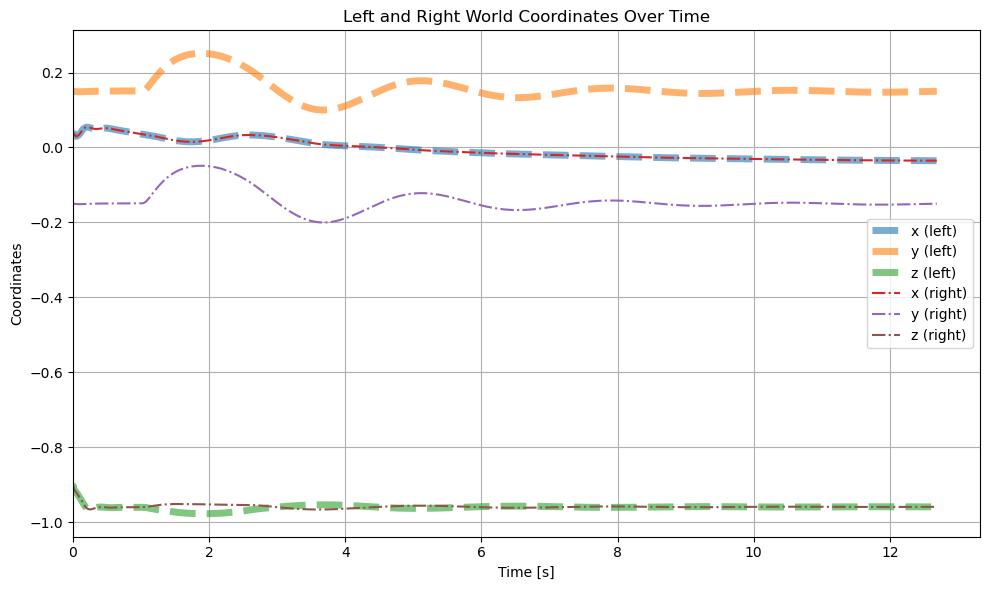

In [ ]:
# Erstelle den Plot
fig, ax = plt.subplots(figsize=(10, 6))
# Plot für left_world Daten
ax.plot(time, left_world[:i, :3], '--', alpha=0.6, linewidth=5, label=['x', 'y', 'z'])
# Plot für right_world Daten
ax.plot(time, right_world[:i, :3], '-.')
# Legende hinzufügen
ax.legend(['x (left)', 'y (left)', 'z (left)', 'x (right)', 'y (right)', 'z (right)'])
# Gitternetzlinien hinzufügen
ax.grid(True)
# Startet den Plot am linken Rand
ax.set_xlim(left=0)
# Titel und Achsenbeschriftungen
ax.set_title('Left and Right Feet World Coordinates')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Position [m]')

# Plot anzeigen
plt.tight_layout()

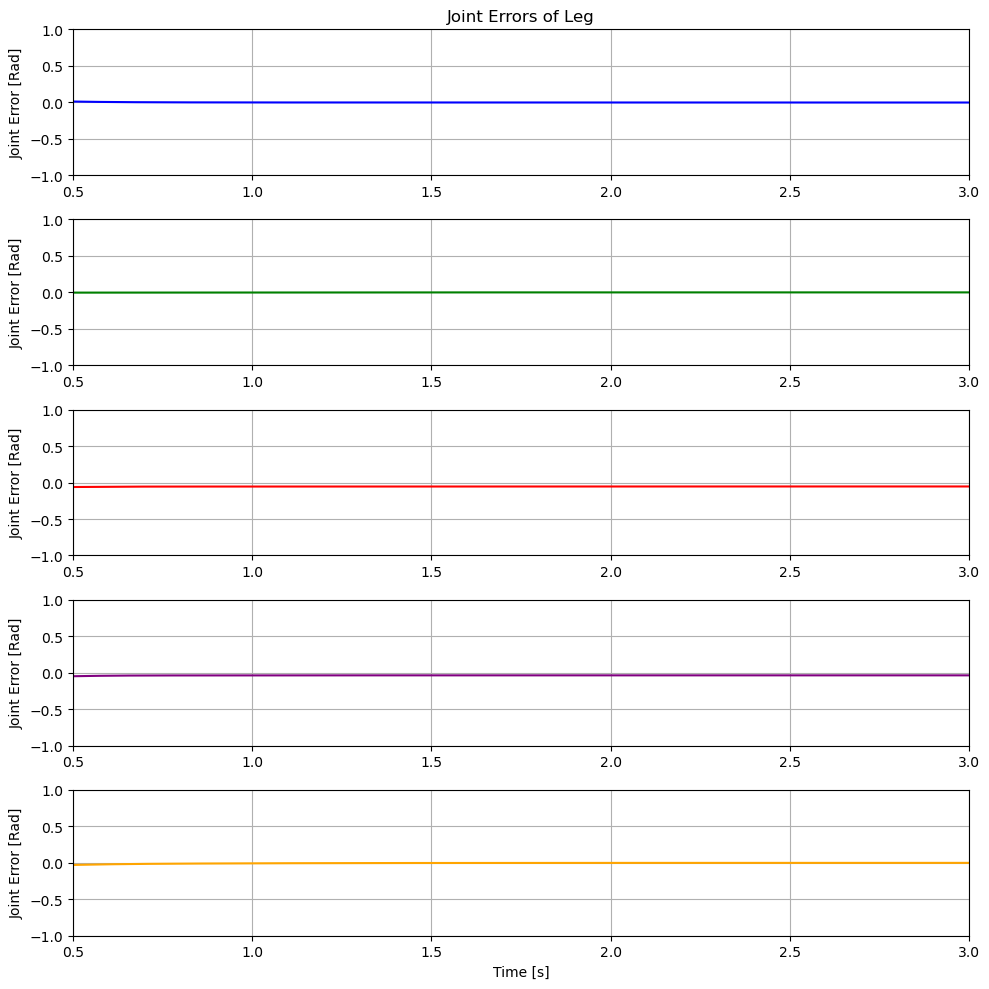

In [ ]:
# Erstelle die Unterplots
fig, ax = plt.subplots(5, 1, figsize=(10, 10))

# Für alle Plots die y-Achsen-Grenzen definieren
y_min = -1  # Untere Grenze der y-Achse (anpassen nach Bedarf)
y_max = 1   # Obere Grenze der y-Achse (anpassen nach Bedarf)

# Plot für die x-Komponente der Beckenposition
ax[0].plot(time, errors_left[:i, 0], color='blue')
ax[0].grid(True)
ax[0].set_xlim(left=0.5, right=3)
ax[0].set_ylim(y_min, y_max)
ax[0].set_title('Joint Errors of Leg')
ax[0].set_ylabel('Joint Error [Rad]')

# Plot für die y-Komponente der Beckenposition
ax[1].plot(time, errors_left[:i, 1], color='green')
ax[1].grid(True)
ax[1].set_xlim(left=0.5, right=3)
ax[1].set_ylim(y_min, y_max)
ax[1].set_ylabel('Joint Error [Rad]')

# Plot für die z-Komponente der Beckenposition
ax[2].plot(time, errors_left[:i, 2], color='red')
ax[2].grid(True)
ax[2].set_xlim(left=0.5, right=3)
ax[2].set_ylim(y_min, y_max)
ax[2].set_ylabel('Joint Error [Rad]')

# Plot für die z-Komponente der Beckenposition
ax[3].plot(time, errors_left[:i, 3], color='purple')
ax[3].grid(True)
ax[3].set_xlim(left=0.5, right=3)
ax[3].set_ylim(y_min, y_max)
ax[3].set_ylabel('Joint Error [Rad]')

# Plot für die z-Komponente der Beckenposition
ax[4].plot(time, errors_left[:i, 4], color='orange')
ax[4].grid(True)
ax[4].set_xlim(left=0.5, right=3)
ax[4].set_ylim(y_min, y_max)
ax[4].set_xlabel('Time [s]')
ax[4].set_ylabel('Joint Error [Rad]')

# Layout-Anpassung für eine bessere Darstellung
plt.tight_layout()
plt.savefig('joint_errors.pdf')
